# For this task: Images were manually procured on Google Images.


In [1]:
!git clone https://github.com/anon5159753/Bundle_Annotating.git

!pip install markdown

Cloning into 'Bundle_Annotating'...
remote: Enumerating objects: 2065, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 2065 (delta 17), reused 0 (delta 0), pack-reused 2029 (from 1)
Receiving objects: 100% (2065/2065), 167.76 MiB | 22.46 MiB/s, done.
Resolving deltas: 100% (151/151), done.
Updating files: 100% (1704/1704), done.


In [2]:
import pandas as pd
import numpy as np
import csv
import pickle
import copy
import re
import random
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
import itertools
import json
from PIL import Image

from IPython.display import display, HTML
import markdown

In [3]:
electronic_info = pd.read_pickle("/content/Bundle_Annotating/electronic_bundle_info.pkl")

electronic_bundles = [
    {"bundle_intent": electronic_info[3][i],
     "items": [{"title": electronic_info[0][i][j],
                "image": "/content/Bundle_Annotating/electronics/" + str(electronic_info[2][i][j]) + ".jpg",
                "description": electronic_info[1][i][j],
                } for j in range(len(electronic_info[0][i]))]

     } for i in range(len(electronic_info[0]))
]


clothing_info = pd.read_pickle("/content/Bundle_Annotating/clothing_bundle_info.pkl")


clothing_bundles = [
    {"bundle_intent": clothing_info[3][i],
     "items": [{"title": clothing_info[0][i][j],
                "image": "/content/Bundle_Annotating/clothing/" + str(clothing_info[2][i][j]) + ".jpg",
                "description": clothing_info[1][i][j],
                } for j in range(len(clothing_info[0][i]))]

     } for i in range(len(clothing_info[0]))
]


food_info = pd.read_pickle("/content/Bundle_Annotating/food_bundle_info.pkl")

food_bundles = [
    {"bundle_intent": food_info[3][i],
     "items": [{"title": food_info[0][i][j],
                "image": "/content/Bundle_Annotating/food/" + str(food_info[2][i][j]) + ".jpg",
                "description": food_info[1][i][j],
                } for j in range(len(food_info[0][i]))]

     } for i in range(len(food_info[0]))
]

In [4]:
display(HTML("<h3>🧩 Your task is to annotate each bundle under your chosen metrics, how you format your answer is your decision.</h3>"))

display(HTML("<h3>The intent provided is to help you understand how the annotator thought about the bundle, however, evaluate the bundle overall quality not just alignment to intent.</h3>"))




[0 1 2 3 4]



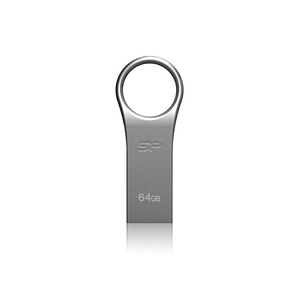

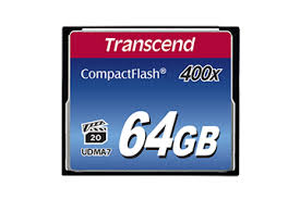

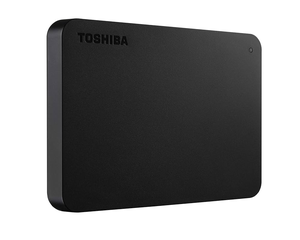

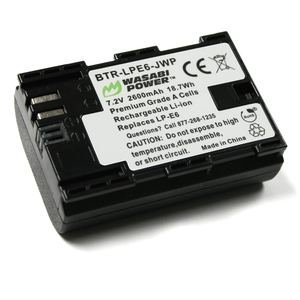

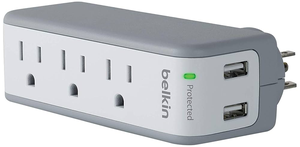

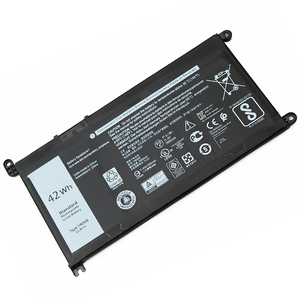

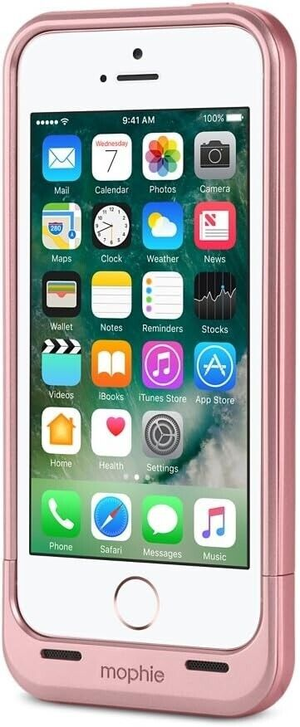

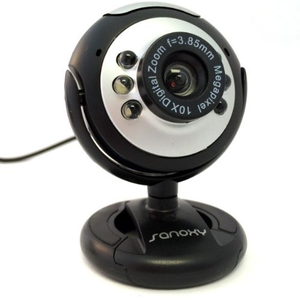

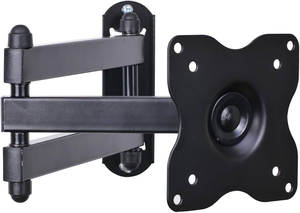

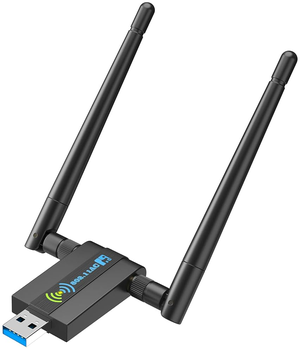

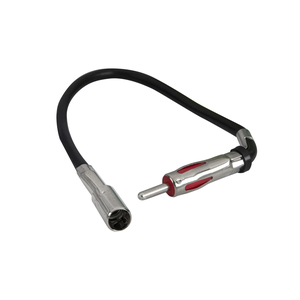

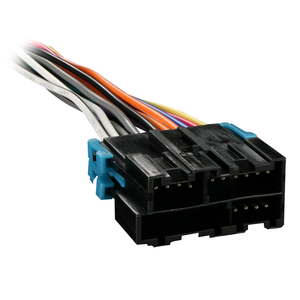

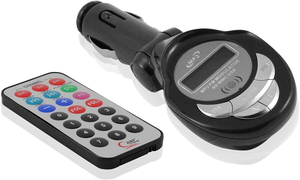

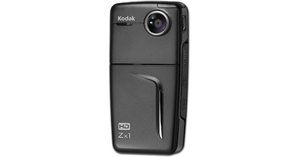

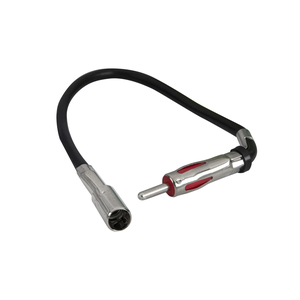

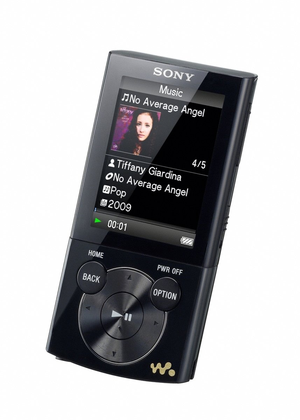

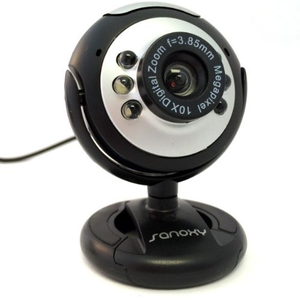

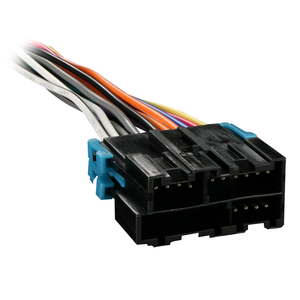

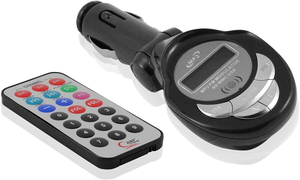

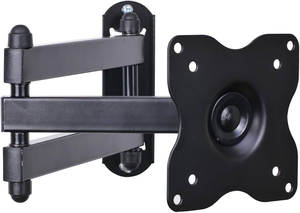

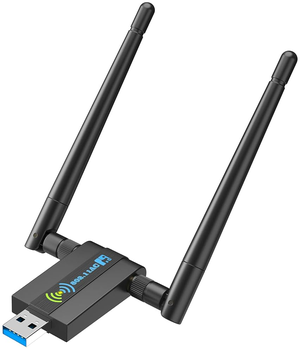

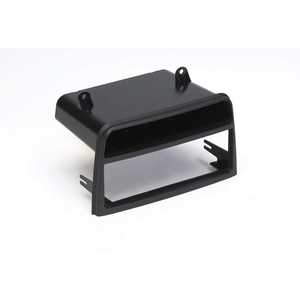

In [5]:
# Setup

vec = np.arange(5)#(len(electronic_bundles))  # Adjust if you have < 40


# To store scores
# scores = {}

print(vec)

print()

# Resize helper
def resize_image(image_path, base_width=300):
    img = Image.open(image_path)
    w_percent = (base_width / float(img.size[0]))
    h_size = int((float(img.size[1]) * float(w_percent)))
    return img.resize((base_width, h_size), Image.LANCZOS)

count = 1

# Loop through shuffled bundles
for idx in vec:
    bundle = electronic_bundles[idx]



    display(HTML(f"<hr><h2>🔢 Bundle {count}: {bundle['bundle_intent']}</h2>"))
    # display(HTML("<h3>📝 Importance Explanation:</h3>"))
    # display(HTML(f"<pre style='font-size:14px'>{bundle['importance_graph']}</pre>"))
    display(HTML("<h3>🧩 Items in this Bundle:</h3>"))



    for item in bundle["items"]:
        img = resize_image(item["image"])
        display(img)
        display(HTML(f"<h4>{item['title']}</h4>"))
        display(HTML(f"<p style='margin-bottom:30px'>{item['description']}</p>"))


    count += 1

[0 1 2 3 4]



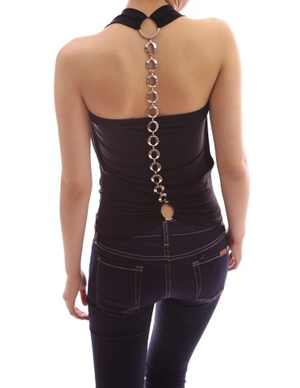

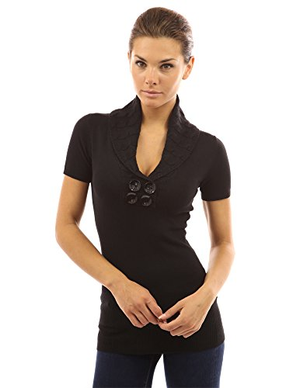

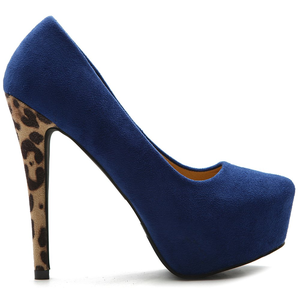

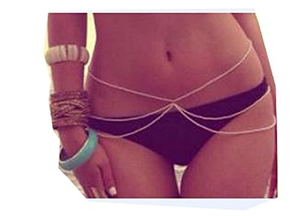

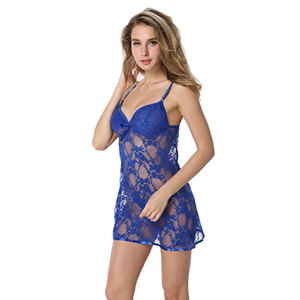

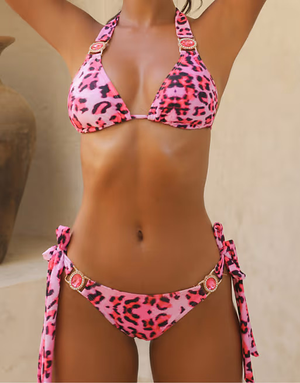

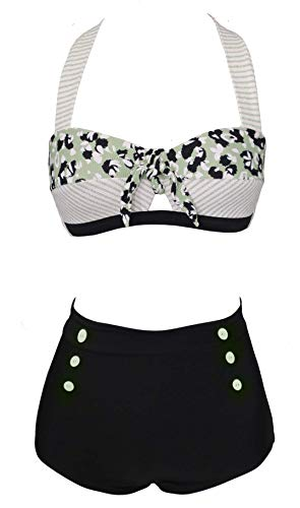

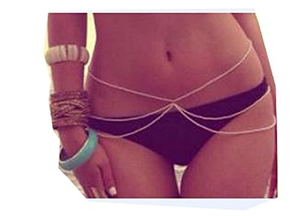

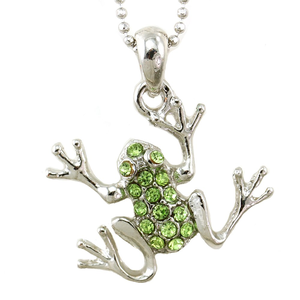

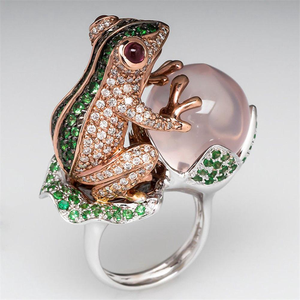

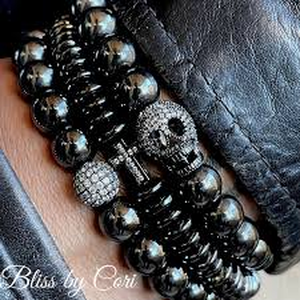

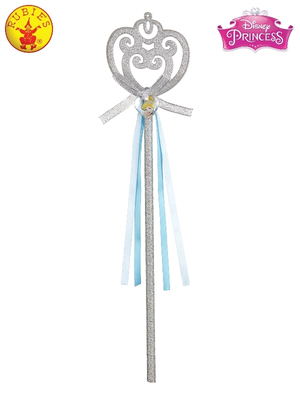

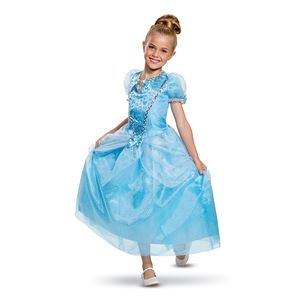

In [6]:
# Setup

vec = np.arange(5)#(len(clothing_bundles))  # Adjust if you have < 40


# To store scores
# scores = {}

print(vec)

print()

# Resize helper
def resize_image(image_path, base_width=300):
    img = Image.open(image_path)
    w_percent = (base_width / float(img.size[0]))
    h_size = int((float(img.size[1]) * float(w_percent)))
    return img.resize((base_width, h_size), Image.LANCZOS)

count = 1

# Loop through shuffled bundles
for idx in vec:
    bundle = clothing_bundles[idx]



    display(HTML(f"<hr><h2>🔢 Bundle {count}: {bundle['bundle_intent']}</h2>"))
    # display(HTML("<h3>📝 Importance Explanation:</h3>"))
    # display(HTML(f"<pre style='font-size:14px'>{bundle['importance_graph']}</pre>"))
    display(HTML("<h3>🧩 Items in this Bundle:</h3>"))



    for item in bundle["items"]:
        img = resize_image(item["image"])
        display(img)
        display(HTML(f"<h4>{item['title']}</h4>"))
        display(HTML(f"<p style='margin-bottom:30px'>{item['description']}</p>"))


    count += 1

[0 1 2 3 4]



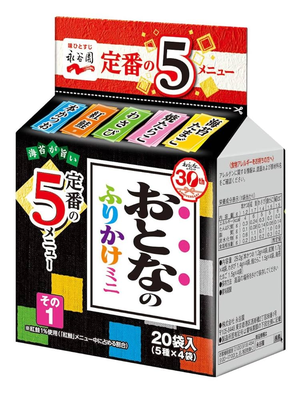

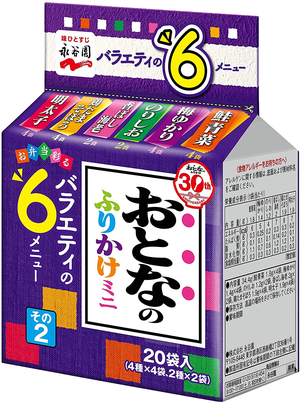

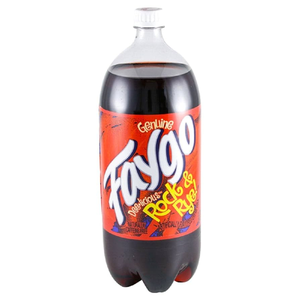

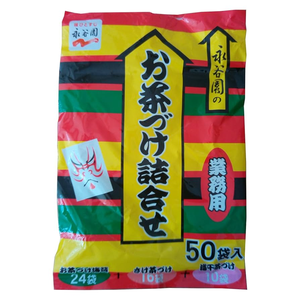

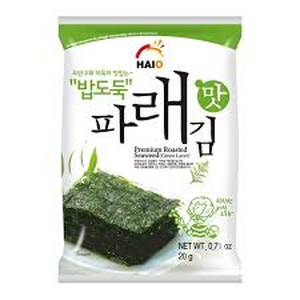

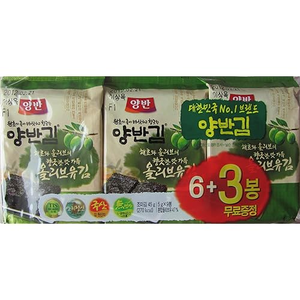

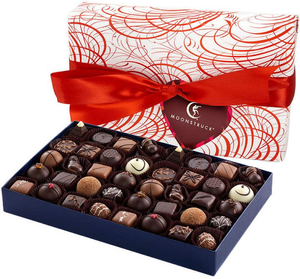

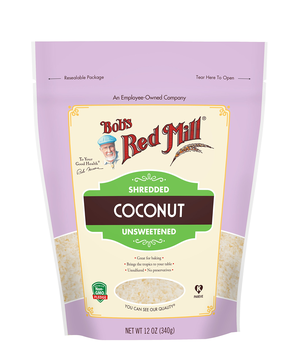

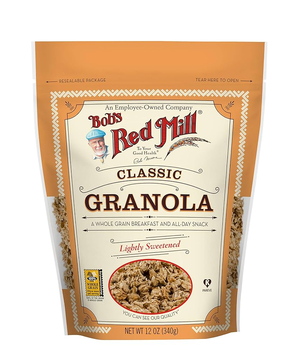

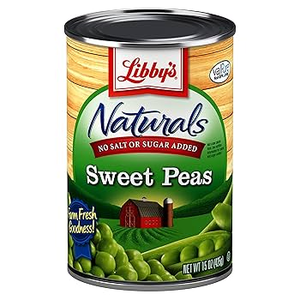

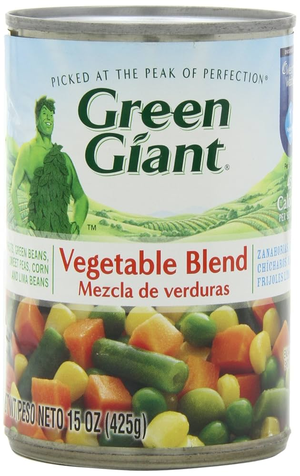

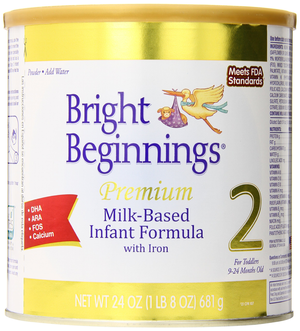

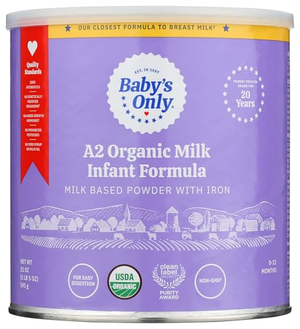

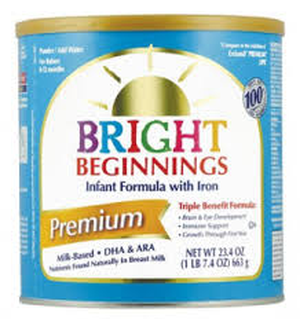

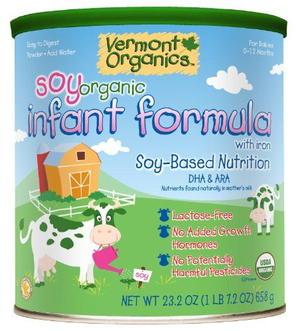

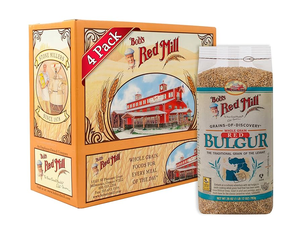

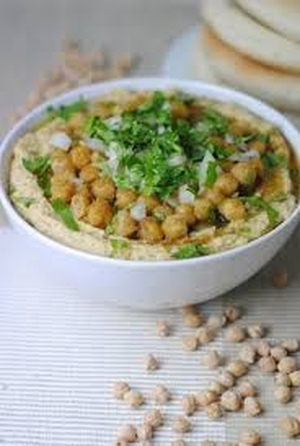

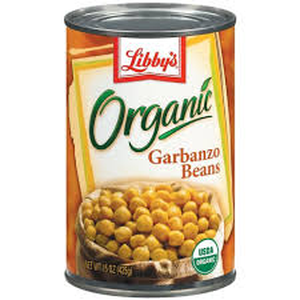

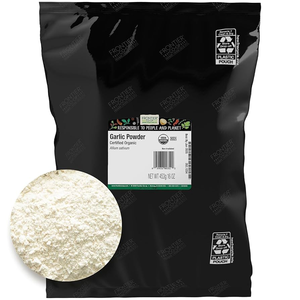

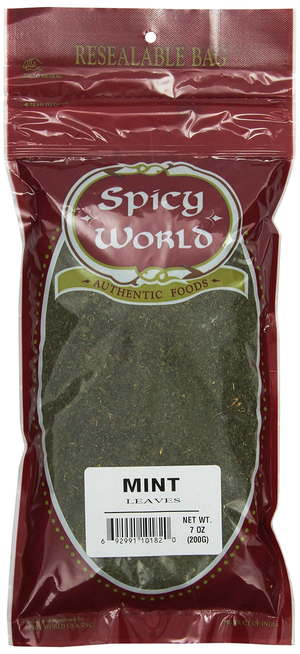

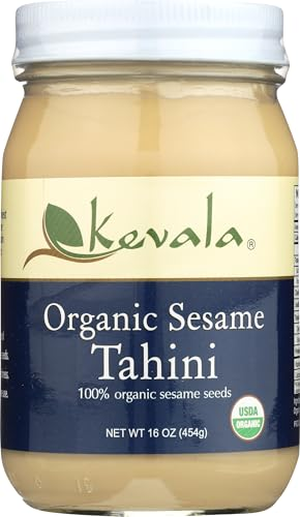

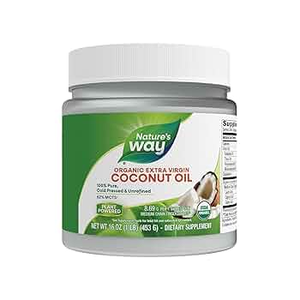

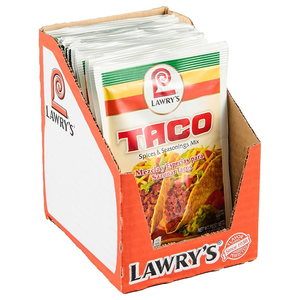

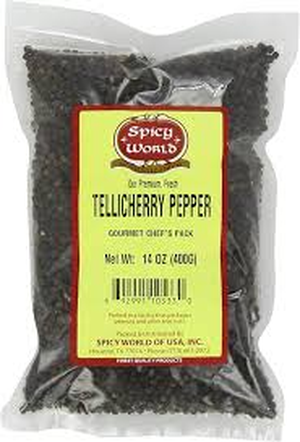

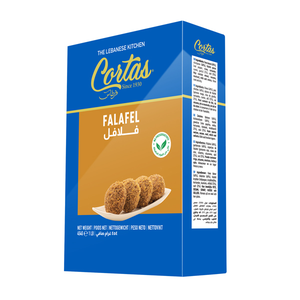

In [7]:
# Setup

vec = np.arange(5)#(150)  # Adjust if you have < 40


# To store scores
# scores = {}

print(vec)

print()

# Resize helper
def resize_image(image_path, base_width=300):
    img = Image.open(image_path)
    w_percent = (base_width / float(img.size[0]))
    h_size = int((float(img.size[1]) * float(w_percent)))
    return img.resize((base_width, h_size), Image.LANCZOS)

count = 1

# Loop through shuffled bundles
for idx in vec:
    bundle = food_bundles[idx]



    display(HTML(f"<hr><h2>🔢 Bundle {count}: {bundle['bundle_intent']}</h2>"))
    # display(HTML("<h3>📝 Importance Explanation:</h3>"))
    # display(HTML(f"<pre style='font-size:14px'>{bundle['importance_graph']}</pre>"))
    display(HTML("<h3>🧩 Items in this Bundle:</h3>"))



    for item in bundle["items"]:
        img = resize_image(item["image"])
        display(img)
        display(HTML(f"<h4>{item['title']}</h4>"))
        display(HTML(f"<p style='margin-bottom:30px'>{item['description']}</p>"))


    count += 1

# After annotating, prepare jsons for EGPO.

In [ ]:
file_path = '/content/Bundle_Annotating/electronic_annotations.xlsx'

df = pd.read_excel(file_path)

print(df.head())



electronic_training_annotations = df.iloc[0:50, 1]

electronic_training_annotations = electronic_training_annotations.tolist()

electronic_training_annotations = [annotations.replace("\n", "") for annotations in electronic_training_annotations]

electronic_bundle_scores = df.iloc[0:72, 2]





file_path = '/content/Bundle_Annotating/clothing_annotations.xlsx'

df = pd.read_excel(file_path)

print(df.head())



clothing_training_annotations = df.iloc[0:50, 1]

clothing_training_annotations = clothing_training_annotations.tolist()

clothing_training_annotations = [annotations.replace("\n", "") for annotations in clothing_training_annotations]

clothing_bundle_scores = df.iloc[0:80, 2]



file_path = '/content/Bundle_Annotating/food_annotations.xlsx'


df = pd.read_excel(file_path)

print(df.head())



food_training_annotations = df.iloc[0:50, 1]

food_training_annotations = food_training_annotations.tolist()

food_training_annotations = [annotations.replace("\n", "") for annotations in food_training_annotations]

food_bundle_scores = df.iloc[0:80, 2]



   Bundle                                         Annotation  Score
0       1  This bundle lacks functionality integration. T...    3.0
1       2  The bundle lacks functionality integration as ...    1.0
2       3  This bundle is tailored to a user which specif...    4.0
3       4  The bundle has a clear intent, to setup a car ...    5.0
4       5  The bundle has items which are not similar at ...    1.0
   Bundle                                         Annotation  Score
0       1  This bundle is easy to understand. The draping...    5.0
1       2  The bundle items each complement each other an...    5.0
2       3  The bundle makes sense. Including a bikini bod...    3.0
3       4  The necklace charm, ring and bracelet are all ...    4.0
4       5  The items fulfill the function of turning a gi...    5.0
   Bundles                                         Annotation  Score  Quality
0        1  The bundle does not integrate functionally as ...    2.0      NaN
1        2  This bundle func

In [ ]:
electronic_info = pd.read_pickle("/content/Bundle_Annotating/electronic_bundle_info.pkl")

clothing_info = pd.read_pickle("/content/Bundle_Annotating/clothing_bundle_info.pkl")

food_info = pd.read_pickle("/content/Bundle_Annotating/food_bundle_info.pkl")

In [ ]:
def input_strings(intent_list, item_list, description_list):
    l = len(intent_list)
    string_list = []
    for i in range(l):
        intent = intent_list[i]
        items = item_list[i]
        descriptions = description_list[i]
        item_str = "\n".join([f"{i + 1}. {title}" for i, title in enumerate(items)])

        string_list.append(f"Intent: {intent}\nBundle Items:\n{item_str}\n")
    return string_list

In [ ]:
electronic_training_string_list = input_strings(electronic_info[3][0:50], electronic_info[0][0:50], electronic_info[1][0:50])

electronic_valid_string_list = input_strings(electronic_info[3][50:72], electronic_info[0][50:72], electronic_info[1][50:72])

clothing_training_string_list = input_strings(clothing_info[3][0:50], clothing_info[0][0:50], clothing_info[1][0:50])

clothing_valid_string_list = input_strings(clothing_info[3][50:80], clothing_info[0][50:80], clothing_info[1][50:80])

food_training_string_list = input_strings(food_info[3][0:50], food_info[0][0:50], food_info[1][0:50])

food_valid_string_list = input_strings(food_info[3][50:80], food_info[0][50:80], food_info[1][50:80])

In [ ]:
data = {}

for i in range(50):
    data[i] = {
        "input": electronic_training_string_list[i],
        "target_score": electronic_bundle_scores[i],
        "annotations": electronic_training_annotations[i]
    }

filename = "electronic_train_50.json"

with open(filename, "w") as f:
    json.dump(data, f, indent = 4)

data = {}

for i in range(50,72):
    data[int(i-50)] = {
        "input": electronic_valid_string_list[int(i-50)],
        "target_score": electronic_bundle_scores[i]
    }

filename = "electronic_valid.json"

with open(filename, "w") as f:
    json.dump(data, f, indent = 4)

In [ ]:
data = {}

for i in range(50):
    data[i] = {
        "input": clothing_training_string_list[i],
        "target_score": clothing_bundle_scores[i],
        "annotations": clothing_training_annotations[i]
    }

filename = "clothing_train_50.json"

with open(filename, "w") as f:
    json.dump(data, f, indent = 4)

    data = {}

for i in range(50,80):
    data[int(i-50)] = {
        "input": clothing_valid_string_list[int(i-50)],
        "target_score": clothing_bundle_scores[i]
    }

filename = "clothing_valid.json"

with open(filename, "w") as f:
    json.dump(data, f, indent = 4)

In [ ]:
data = {}

for i in range(50):
    data[i] = {
        "input": food_training_string_list[i],
        "target_score": food_bundle_scores[i],
        "annotations": food_training_annotations[i]
    }

filename = "food_train_50.json"

with open(filename, "w") as f:
    json.dump(data, f, indent = 4)

data = {}

for i in range(50,80):
    data[int(i-50)] = {
        "input": food_valid_string_list[int(i-50)],
        "target_score": food_bundle_scores[i]
    }

filename = "food_valid.json"

with open(filename, "w") as f:
    json.dump(data, f, indent = 4)